In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import numpy as np

In [2]:
dados = pd.read_csv('dados_planta.csv')
print("Shape:", dados.shape)
print("Colunas:", dados.columns.tolist())


Shape: (132478, 16)
Colunas: ['TS', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'TARGET', 'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15']


In [3]:
nulos = dados.isnull().sum()
print(nulos[nulos > 0])
print(f"\nTotal de linhas: {len(dados)}")

var1      110
var2      108
var3      116
var4      449
var5      108
var6      109
TARGET    430
var8      110
var9      110
var10     538
var11     420
var12     238
var13     280
var14     109
var15     108
dtype: int64

Total de linhas: 132478


In [4]:
total_linhas = len(dados)

for col in dados.columns:
    n = dados[col].isnull().sum()
    if n > 0:
        pct = n / total_linhas * 100
        print(f"{col}: {n} NaN ({pct:.1f}% das linhas)")

var1: 110 NaN (0.1% das linhas)
var2: 108 NaN (0.1% das linhas)
var3: 116 NaN (0.1% das linhas)
var4: 449 NaN (0.3% das linhas)
var5: 108 NaN (0.1% das linhas)
var6: 109 NaN (0.1% das linhas)
TARGET: 430 NaN (0.3% das linhas)
var8: 110 NaN (0.1% das linhas)
var9: 110 NaN (0.1% das linhas)
var10: 538 NaN (0.4% das linhas)
var11: 420 NaN (0.3% das linhas)
var12: 238 NaN (0.2% das linhas)
var13: 280 NaN (0.2% das linhas)
var14: 109 NaN (0.1% das linhas)
var15: 108 NaN (0.1% das linhas)


In [5]:
dados_novo = dados.copy()        # cria cópia (opcional)
dados = dados_novo.ffill()       # ou dados = dados.ffill()

In [6]:
restantes = dados.isnull().sum().sum()
print(f"NaN restantes após ffill: {restantes}")

NaN restantes após ffill: 0


## Tratamento de valores faltantes

Encontrei NaN nas colunas [var]. 
Representam 0,05% dos dados.

Estratégia escolhida: forward fill (ffill).
Justificativa: em sensores industriais, a perda de sinal momentânea 
não significa que o processo parou — o valor anterior é a melhor 
estimativa do estado real naquele instante.

In [7]:
dados_novo['var4'].nunique()

4761

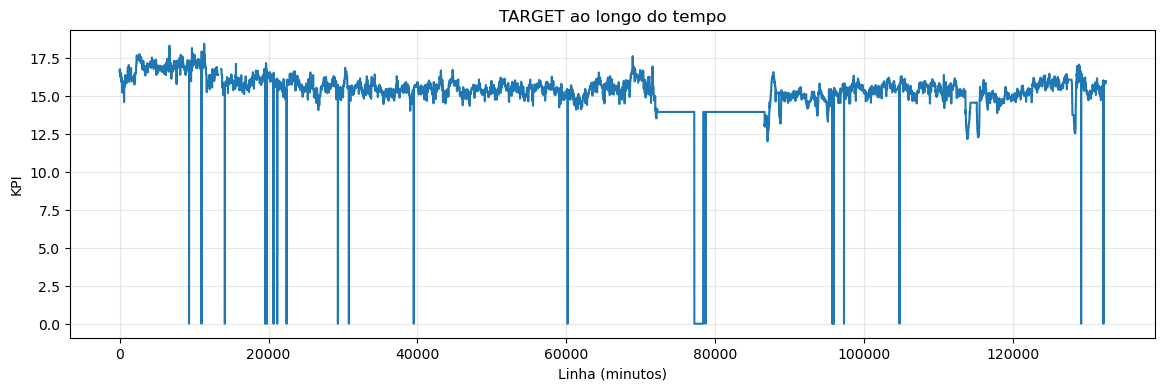

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(dados_novo['TARGET'].values)
plt.title('TARGET ao longo do tempo')
plt.xlabel('Linha (minutos)')
plt.ylabel('KPI')
plt.grid(True, alpha=0.3)
plt.show()

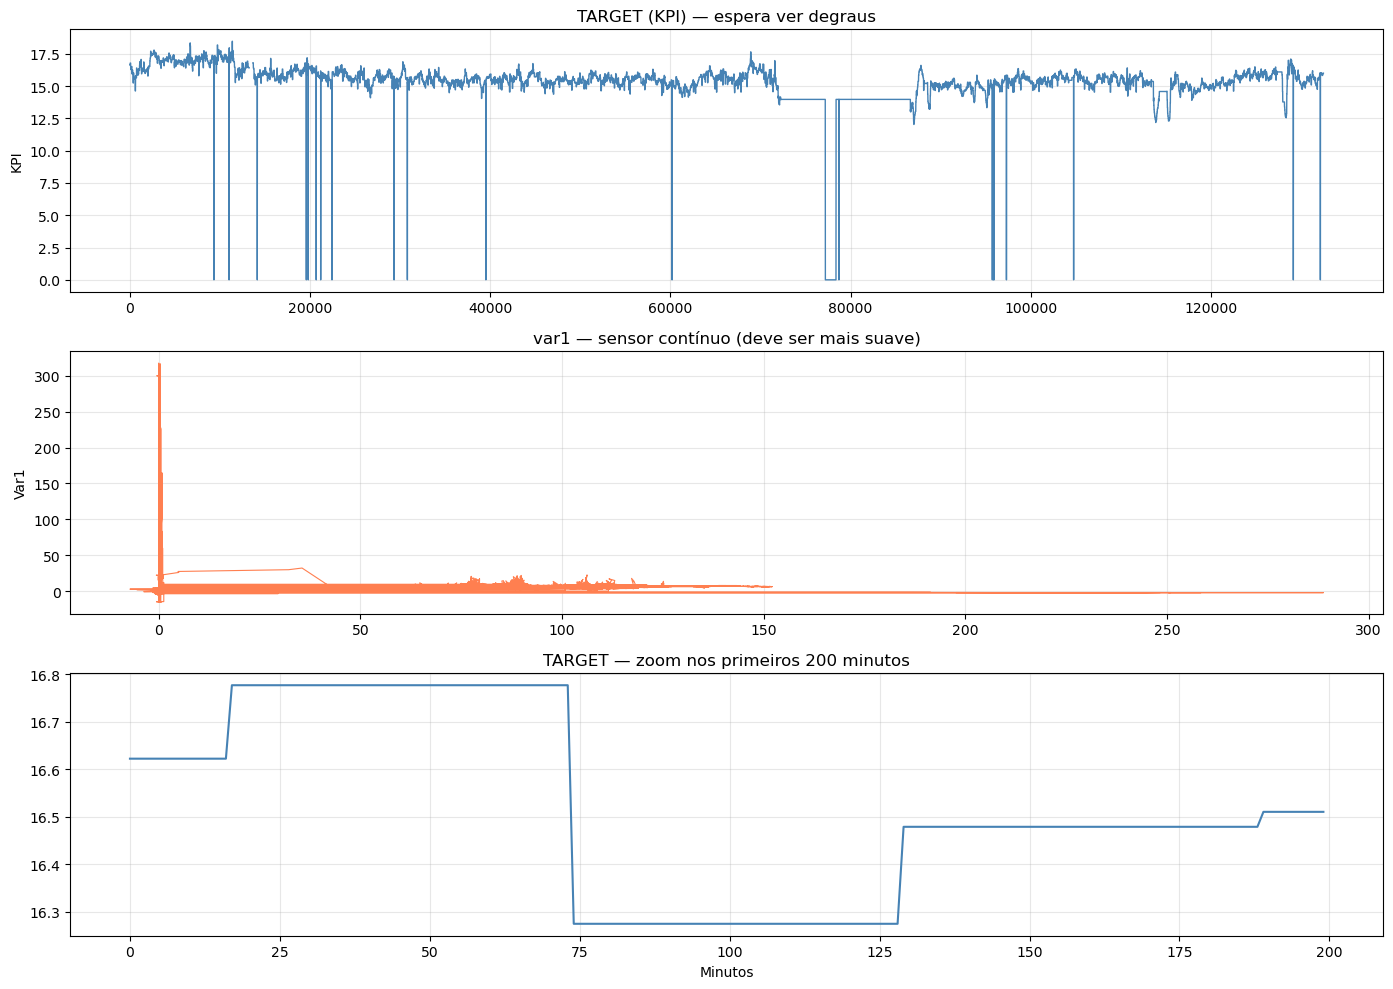

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# TARGET — você vai ver os degraus de 30min
axes[0].plot(dados_novo['TARGET'].values, color='steelblue', linewidth=1)
axes[0].set_title('TARGET (KPI) — espera ver degraus')
axes[0].set_ylabel('KPI')
axes[0].grid(True, alpha=0.3)

# Var1 — sensor contínuo de 1min pra comparar
axes[1].plot(dados_novo['var1'], dados['var3'].values, color='coral', linewidth=0.8)
axes[1].set_title('var1 — sensor contínuo (deve ser mais suave)')
axes[1].set_ylabel('Var1')
axes[1].grid(True, alpha=0.3)

# Zoom nos primeiros 200 pontos pra ver o padrão de perto
axes[2].plot(dados_novo['TARGET'].values[:200], color='steelblue', linewidth=1.5)
axes[2].set_title('TARGET — zoom nos primeiros 200 minutos')
axes[2].set_xlabel('Minutos')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

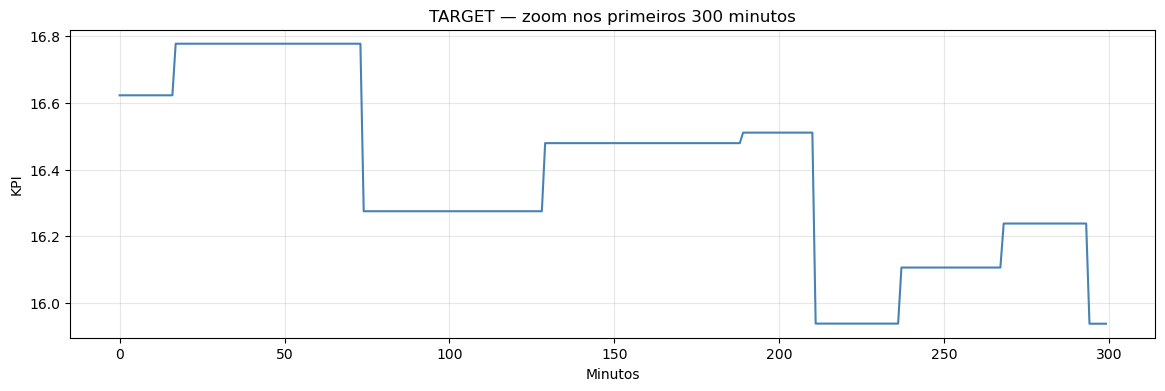

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(dados_novo['TARGET'][:300].values, color='steelblue', linewidth=1.5)
plt.title('TARGET — zoom nos primeiros 300 minutos')
plt.xlabel('Minutos')
plt.ylabel('KPI')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
dados_novo.min()

TS        2025-10-01 00:00:00 -04:00
var1                       -7.153759
var2                        -28.4729
var3                       -14.96452
var4                             0.0
var5                       -70.60547
var6                             0.0
TARGET                           0.0
var8                       -142.3645
var9                       -3.699641
var10                      -16.57643
var11                            0.0
var12                            0.0
var13                            0.0
var14                    -36143610.0
var15                     -39.977337
dtype: object

### Hipótese 1 - Os sensores de processo mudam enquanto o KPI está travado?

Se os sensores mudam e o KPI não, isso confirma que estamos recebendo informação nos sensores que antecipa a próxima leitura. Vamos explorar mais


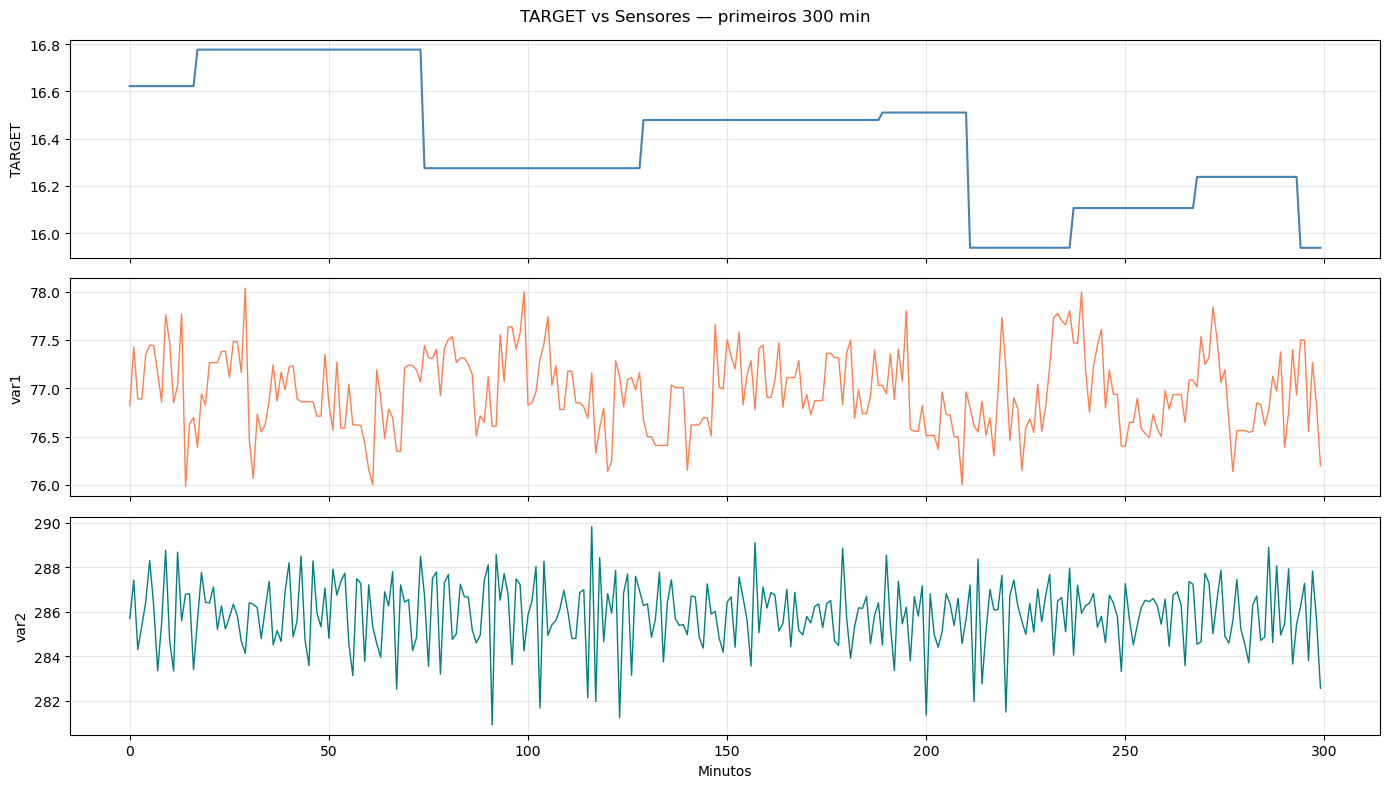

In [12]:
# Veja Var1 e Var2 no mesmo período e compare com TARGET
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dados_novo['TARGET'].values[:300], color='steelblue', linewidth=1.5)
axes[0].set_ylabel('TARGET')
axes[0].grid(True, alpha=0.3)

axes[1].plot(dados_novo['var1'].values[:300], color='coral', linewidth=1)
axes[1].set_ylabel('var1')
axes[1].grid(True, alpha=0.3)

axes[2].plot(dados_novo['var2'].values[:300], color='teal', linewidth=1)
axes[2].set_ylabel('var2')
axes[2].set_xlabel('Minutos')
axes[2].grid(True, alpha=0.3)

plt.suptitle('TARGET vs Sensores — primeiros 300 min')
plt.tight_layout()
plt.show()

In [13]:
# Quantificar os eventos anormais
zeros = (dados_novo['TARGET'] < 5).sum()
pct_zeros = zeros / len(dados_novo) * 100

print(f"Pontos com TARGET < 5: {zeros}")
print(f"Percentual dos dados: {pct_zeros:.2f}%")
print(f"\nEstatísticas da TARGET (com zeros):")
print(dados_novo['TARGET'].describe().round(3))

Pontos com TARGET < 5: 1242
Percentual dos dados: 0.94%

Estatísticas da TARGET (com zeros):
count    132048.000
mean         15.283
std           1.719
min           0.000
25%          15.012
50%          15.477
75%          15.876
max          18.465
Name: TARGET, dtype: float64


## EDA — 1.1 Qualidade e distribuição da TARGET

**Pergunta:** a TARGET tem anomalias que precisam ser tratadas antes do treino?

**Achados:**
- Dataset: 132.048 linhas × [N] colunas (~3 meses de dados a 1 minuto)
- Faixa de operação normal: 15.01 a 15.88 (IQR)
- Média: 15.28 | Desvio padrão: 1.72
- Pontos com TARGET < 5 (zeros): 1.242 pontos = 0,94% dos dados

**Hipótese levantada:** valores de TARGET igual a zero não representam 
operação real do processo — indicam paradas de linha ou falha do sensor 
óptico. Um sensor de qualidade óptica não registra zero em operação normal.

**Decisão (a executar no pré-processamento):** remover as 1.242 linhas 
com TARGET < 5 antes do treino para evitar que o modelo aprenda 
a prever zero em condições normais de operação.

In [14]:
# Valores únicos por coluna — revela variáveis sem informação
unicos = dados_novo.nunique().sort_values()
print("Valores únicos por coluna:")
print(unicos)

print(f"\nvar4 — mín: {dados_novo['var4'].min()}, máx: {dados_novo['var4'].max()}, únicos: {dados_novo['var4'].nunique()}")

Valores únicos por coluna:
var12         19
var11         25
TARGET      3273
var13       3565
var4        4761
var10       7569
var3       44706
var6       73558
var8       94100
var9       97724
var1      101950
var2      107150
var14     110893
var15     114417
var5      122209
TS        132478
dtype: int64

var4 — mín: 0.0, máx: 159.6021, únicos: 4761


## EDA — 1.2 Variabilidade das features (valores únicos)

**Pergunta:** todas as variáveis têm informação suficiente para o modelo?

**Método:** contagem de valores únicos por coluna. 
Um sensor contínuo saudável em 132k leituras deve ter dezenas de milhares 
de únicos. Poucos únicos indicam sensor lento, setpoint ou variável categórica.

**Achados:**

| Variável | Únicos | Interpretação |
|---|---|---|
| var12 | 19 | Sensor lento ou setpoint — investigar |
| var11 | 25 | Mesmo padrão — investigar |
| TARGET | 3.273 | Esperado — sensor de 30min trava entre leituras |
| var4 | 4.761 | Varia — suspeita de constante descartada |
| var1, var2, var5... | 100k+ | Sensores contínuos saudáveis |
| TS | 132.478 | Timestamp identificado — quase 1 único por linha |

**Hipóteses levantadas:**
- `var12` e `var11` podem representar modo de operação ou turno do processo
- Se confirmado, são features potencialmente poderosas para distinguir 
  regimes de operação diferentes
- `TS` deve ser convertido para datetime para extrair hora e dia da semana

**Próximo passo:** inspecionar os valores possíveis de var12 e var11

### Investigando var11 e var12 — parecem ser constantes ou quase constantes

In [15]:
### investigando var11 e var12 — parecem ser constantes ou quase constantes

print("var11 — valores possíveis:")
print(sorted(dados_novo['var11'].unique()))
print("\nvar12 — valores possíveis:")
print(sorted(dados_novo['var12'].unique()))

var11 — valores possíveis:
[0.0, 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12.0, 12.1, 12.2, 12.3, 12.4, 12.5, 12.6, nan, 12.7, 12.8, 12.9, 13.0, 13.1, 13.2, 15.0, 20.0]

var12 — valores possíveis:
[0.0, 6.0, 6.5, 6.6, 6.7, 6.8, 6.85, 6.9, 7.0, 7.1, 7.2, 7.25, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, nan, 8.0]


## EDA — 1.3 Investigação de var11 e var12

**Pergunta:** var11 e var12 são categóricas, constantes ou setpoints?

**Resultado da inspeção:**

- `var12`: 19 valores no intervalo 6.0–8.0 com incrementos manuais
- `var11`: 25 valores no intervalo 11.1–13.2, com dois outliers (15.0 e 20.0)
- Ambas contêm 0.0 e NaN — associados a paradas de processo
- Padrão de incrementos decimais regulares confirma: são setpoints de processo

**Interpretação:** setpoints são parâmetros definidos manualmente pelo 
operador. Quando mudam, sinalizam uma intenção de alterar o comportamento 
do processo — e provavelmente antecedem mudanças no KPI.

**Hipótese:** var11 e var12 têm poder preditivo indireto — não por variação 
contínua, mas por sinalizar mudanças de regime operacional.

**Atenção:** os valores 15.0 e 20.0 em var11 estão fora do cluster principal 
(11–13). Investigar se coincidem com o regime diferente detectado entre 
as linhas ~80k–90k no gráfico geral da TARGET.

**Decisão tomada:** mantive ambas no modelo. Tratar 0.0 nas var11 e var12 como parada — 
removerei junto com as linhas onde TARGET < 5 no pré-processamento.

In [16]:
dados_novo.to_csv('dados_planta_limpos.csv', index=True)

In [17]:
total = len(dados_novo)

print("=== RAIO-X DE NaN POR COLUNA ===\n")
for col in dados_novo.columns:
    n = dados_novo[col].isnull().sum()
    pct = n / total * 100
    barra = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
    print(f"{col:<10} {n:>7} NaN  ({pct:>5.1f}%)  {barra}")

print(f"\nTotal de linhas: {total}")
print(f"Total de células vazias: {dados_novo.isnull().sum().sum()}")

=== RAIO-X DE NaN POR COLUNA ===

TS               0 NaN  (  0.0%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var1           110 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var2           108 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var3           116 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var4           449 NaN  (  0.3%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var5           108 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var6           109 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
TARGET         430 NaN  (  0.3%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var8           110 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var9           110 NaN  (  0.1%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var10          538 NaN  (  0.4%)  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
var11          420 NaN  (  0.3%

## EDA — Nota de validação dos dados

**Verificação de integridade:** parei durante 20 minutos para a análise visual do CSV, 
foi identificada aparente inconsistência nas datas juntamente com valores NaN.

**Investigação:** ao comparar o arquivo original com o arquivo pré limpo (dados_novo), confirmou-se que os dados estavam ordenados de forma 
descendente na visualização — não havia inconsistência real.

**Conclusão:** dataset íntegro. Período confirmado: 3 meses completos 
de dados contínuos a 1 minuto de resolução.

**Aprendizado:** olhar o arquivo CSV complementa a análise 
exploratória — inconsistências aparentes devem ser investigadas 
antes de qualquer decisão sobre os dados.

#### verificar pra amanhã o numero de celulas vazias e o que fazer com elas

In [18]:
dados_novo = dados_novo.ffill()
dados_novo.to_csv('dados_planta_limpos.csv', index=True)

In [19]:
print("NaN após tratamento:", dados_novo.isnull().sum().sum())

NaN após tratamento: 0


## Pré-processamento — Tratamento de valores ausentes

**Diagnóstico:** 3.343 células vazias distribuídas em 15 colunas.
Nenhuma coluna ultrapassa 0.4% de NaN.

| Coluna | NaN | % |
|---|---|---|
| var10 | 538 | 0.4% |
| var4 | 449 | 0.3% |
| TARGET | 430 | 0.3% |
| var11 | 420 | 0.3% |
| var13 | 280 | 0.2% |
| var12 | 238 | 0.2% |
| demais | <120 | 0.1% |

**Estratégia escolhida:** forward fill (ffill)

**Justificativa:** falhas pontuais de sensor em processo industrial 
não significam ausência de processo — o equipamento continua operando. 
O último valor válido registrado é a melhor estimativa do estado real 
naquele instante, que é exatamente o que o ffill reproduz.
Percentuais abaixo de 0.5% não justificam estratégias mais complexas.

**Resultado:** 0 NaN restantes.

## EDA — 1.4 Análise de amplitude e outliers por variável

**Pergunta:** os valores mínimos e máximos de cada sensor fazem 
sentido físico? Existem leituras absurdas que indicam falha de sensor 
ou outlier?

**Método:** análise de min, max, média e desvio padrão por coluna.

In [20]:
# Seleciona só colunas numéricas antes de calcular
dados_novo = dados_novo.select_dtypes(include='number')

resumo = pd.DataFrame({
    'min':   dados_novo.min().round(2),
    'max':   dados_novo.max().round(2),
    'média': dados_novo.mean().round(2),
    'std':   dados_novo.std().round(2),
})

print(resumo)

                min          max    média        std
var1          -7.15       288.80    81.22      34.26
var2         -28.47       377.61   219.96      98.72
var3         -14.96       317.51     5.80      12.76
var4           0.00       159.60   137.42      37.28
var5         -70.61       876.82   577.64     230.33
var6           0.00       115.82    89.36      21.34
TARGET         0.00        18.47    15.29       1.72
var8        -142.36      1680.84   368.81     146.32
var9          -3.70       531.71   342.75     134.65
var10        -16.58       104.40    64.16      29.17
var11          0.00        20.00    11.89       1.14
var12          0.00         8.00     7.16       0.32
var13          0.00       927.30   350.34     130.76
var14  -36143610.00  21181090.00  1883.97  166093.89
var15        -39.98      1313.81   159.60      62.98


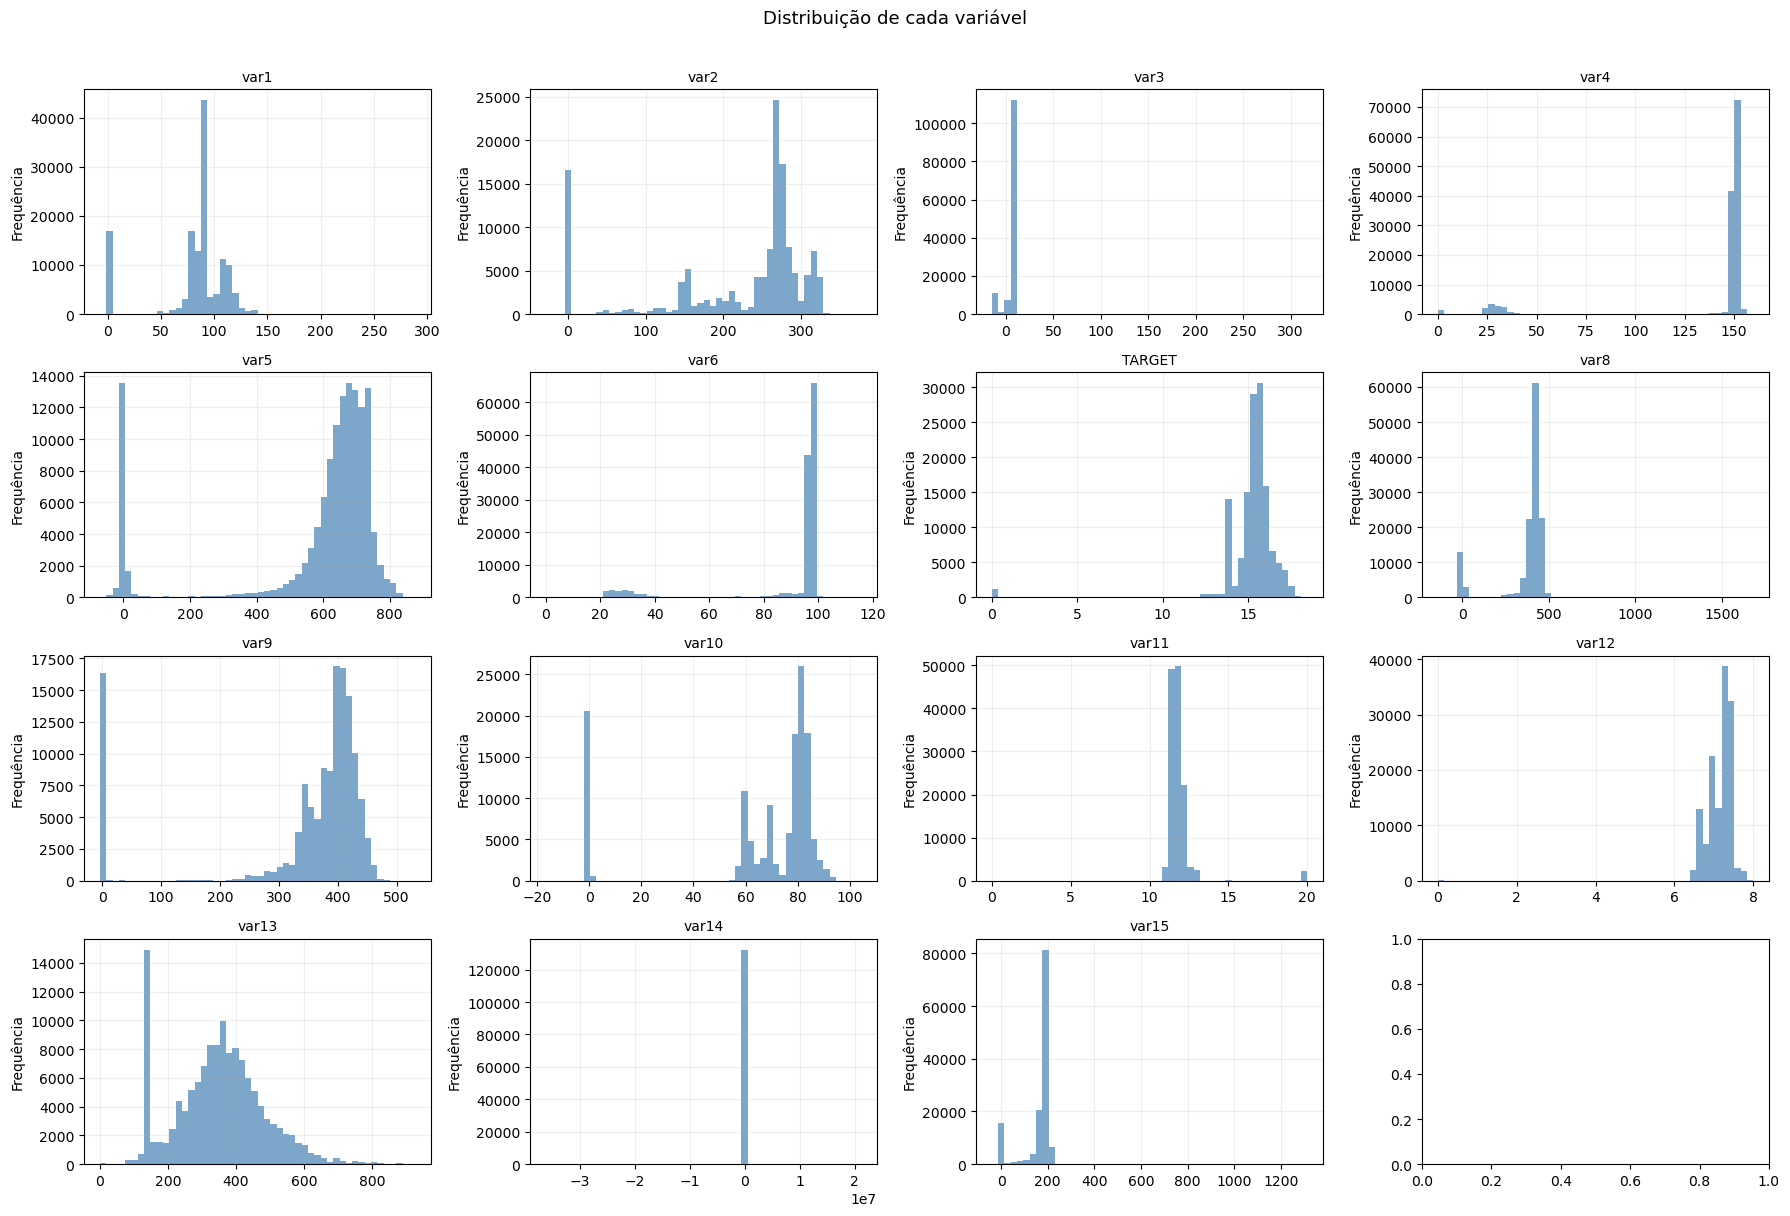

In [21]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(dados_novo.columns):
    axes[i].hist(dados_novo[col].dropna(), bins=50, 
                 color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Distribuição de cada variável', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## EDA — 1.5 Investigação de var14
**Pergunta:** os valores extremos de var14 são outliers reais ou 
propagação de dado corrompido pelo ffill?

In [22]:
dados_novo = dados_novo.reset_index()

In [23]:
print(dados_novo.columns.tolist())
print(dados_novo.index)

['index', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'TARGET', 'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15']
RangeIndex(start=0, stop=132478, step=1)


## Nota técnica — coluna TS

Durante o salvamento do CSV intermediário, a coluna de timestamp `TS` 
foi convertida em índice e recarregada como coluna `'index'`.
Corrigido com rename antes de prosseguir.

In [24]:
dados_novo = dados_novo.rename(columns={'index': 'TS'})

In [25]:
# Ver os valores extremos de var14 e quando ocorrem
var14_extremos = dados_novo[dados_novo['var14'].abs() > 1000][['TS', 'var14']]
print(f"Linhas com var14 extremo (>1000 ou <-1000): {len(var14_extremos)}")
print(var14_extremos.head(20))

Linhas com var14 extremo (>1000 ou <-1000): 14340
          TS     var14
72216  72216  3111.133
72217  72217 -1415.880
72218  72218 -1415.880
72219  72219 -1415.880
72220  72220 -1415.880
72221  72221 -1415.880
72222  72222 -1415.880
72223  72223 -1415.880
72224  72224 -1415.880
72225  72225 -1415.880
72226  72226 -1415.880
72227  72227 -1415.880
72228  72228 -1415.880
72229  72229 -1415.880
72230  72230 -1415.880
72231  72231 -1415.880
72232  72232 -1415.880
72233  72233 -1415.880
72234  72234 -1415.880
72235  72235 -1415.880


## EDA — 1.6 Decisão sobre var14

**Achado:** 14.340 linhas com valores extremos (>1000 ou <-1000) 
concentradas a partir da linha 72.216.

**Causa identificada:** valor corrompido de 3.111 na linha 72.216 
foi propagado pelo ffill como -1.415 por 14.339 linhas consecutivas.

**Impacto:** 10.8% dos dados contaminados por uma única falha de sensor.

**Decisão: remover a coluna var14 inteira.**

**Justificativa:** sem informação adicional sobre o sensor, não é 
possível distinguir valores reais de valores propagados. Remover 
linhas seria arriscado — poderia eliminar período de operação real 
válido nas demais variáveis. A remoção da coluna é a decisão mais 
conservadora e defensável dentro do escopo do projeto.

In [26]:
# Remover var14 do dataframe
dados_novo = dados_novo.drop(columns=['var14'])

# Confirmar remoção
print("Colunas restantes:", dados_novo.columns.tolist())
print("Shape após remoção:", dados_novo.shape)

Colunas restantes: ['TS', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'TARGET', 'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var15']
Shape após remoção: (132478, 15)


## EDA — 1.7 Correlação das variáveis com TARGET (Bloco D)

**Pergunta:** quais sensores têm maior relação linear com o KPI?
**Método:** correlação de Pearson absoluta com TARGET.

Correlação com TARGET:
var4     0.561
var6     0.550
var2     0.511
var10    0.509
var13    0.502
var15    0.496
var5     0.489
var8     0.469
var9     0.463
var1     0.395
TS       0.249
var3     0.149
var11    0.088
var12    0.070
Name: TARGET, dtype: float64


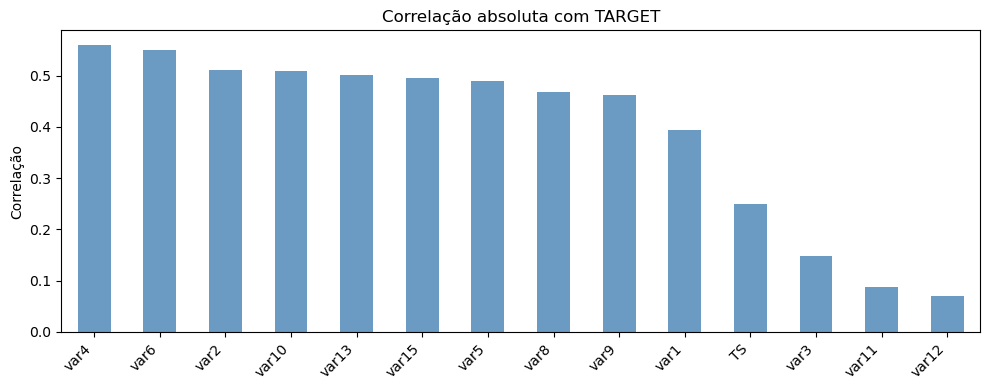

In [27]:
corr = dados_novo.corr()['TARGET'].drop('TARGET')
corr_abs = corr.abs().sort_values(ascending=False)

print("Correlação com TARGET:")
print(corr_abs.round(3))

corr_abs.plot(kind='bar', figsize=(10, 4),
              color='steelblue', alpha=0.8)
plt.title('Correlação absoluta com TARGET')
plt.ylabel('Correlação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## EDA — 1.7 Correlação das variáveis com TARGET

**Resultado:** nenhuma variável tem correlação isolada forte (>0.8).
As mais correlacionadas são var4 (0.56), var6 (0.55) e var2 (0.51).

**Interpretação:** correlação moderada é esperada em processos 
industriais — o KPI é função da combinação de todas as variáveis, 
não de uma isolada. Isso justifica o uso de ML em vez de regressão 
simples: o modelo captura interações que a correlação linear não vê.

**var11 e var12** apresentam correlação baixa (0.07–0.09), mas são 
mantidas por representarem setpoints operacionais — sua influência 
é discreta, não linear.

In [28]:
#salvando arquivo csv limpo
dados_novo.to_csv('dados_planta_limpos.csv', index=False)